# Poisson equation with Nitsche boundary conditions

$$
\mathbb{S}_u
\begin{cases}
\Omega = [0, L_x] \times [0, L_y] \\
u_{\text{D}}(x,y=0)=0 \\
u_{\text{D}}(x,y=L_y)=1 \\
u_{\text{D}}(x=0,y)=y/L_y \\
u_{\text{N}}(x=L_x,y)=y(L_y - y) \\
f(x, y) = x + y^2  
\end{cases}
$$

In [ ]:
from dolfinx.fem import FunctionSpace
from lucifex.mesh import rectangle_mesh, mesh_boundary
from lucifex.fem import Function, cross_section_grid
from lucifex.solver import bvp, BoundaryConditions
from lucifex.plt import plot_colormap, plot_line, save_figure
from lucifex.pde.poisson import nitsche_poisson

Lx = 2.0
Ly = 1.0
mesh = rectangle_mesh(Lx, Ly, 20, 10)
boundary = mesh_boundary(
    mesh, 
    {
        "left": lambda x: x[0],
        "right": lambda x: x[0] - Lx,
        "lower": lambda x: x[1],
        "upper": lambda x: x[1] - Ly,
    },
)

fs = FunctionSpace(mesh, ('P', 1))
f = Function(fs, lambda x: x[0] + x[1] **2, name='f')

alpha = 10.0
bcs = BoundaryConditions(
    ("dirichlet", boundary['lower'], 0.0),
    ("dirichlet", boundary['upper'], 1.0),  
    ("dirichlet", boundary['left'], lambda x: x[1] / Ly), 
    ("neumann", boundary["right"], lambda x: x[1] * (Ly - x[1])),
)
u = Function(fs, name='u')
u_solver = bvp(nitsche_poisson)(u, f, alpha, bcs)
u_solver.solve()

INFO:root:running build_ext


INFO:root:building 'libffcx_forms_e7fce391c9942534cabadf61f1a91b98fb45c55b' extension


INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -I/Users/George/miniconda3/envs/lucifex/lib/python3.10/site-packages/ffcx/codegeneration -I/Users/George/miniconda3/envs/lucifex/include/python3.10 -c libffcx_forms_e7fce391c9942534cabadf61f1a91b98fb45c55b.c -o ./libffcx_forms_e7fce391c9942534cabadf61f1a91b98fb45c55b.o -O2 -g0


INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib ./libffcx_forms_e7fce391c9942534cabadf61f1a91b98fb45c55b.o -o ./libffcx_forms_e7fce391c9942534cabadf61f1a91b98fb45c55b.cpython-310-darwin.so


INFO:root:running build_ext


INFO:root:building 'libffcx_forms_e352123791fa4592f451a7a29a1fc2d52cf14f1f' extension


INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -I/Users/George/miniconda3/envs/lucifex/lib/python3.10/site-packages/ffcx/codegeneration -I/Users/George/miniconda3/envs/lucifex/include/python3.10 -c libffcx_forms_e352123791fa4592f451a7a29a1fc2d52cf14f1f.c -o ./libffcx_forms_e352123791fa4592f451a7a29a1fc2d52cf14f1f.o -O2 -g0


INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib ./libffcx_forms_e352123791fa4592f451a7a29a1fc2d52cf14f1f.o -o ./libffcx_forms_e352123791fa4592f451a7a29a1fc2d52cf14f1f.cpython-310-darwin.so


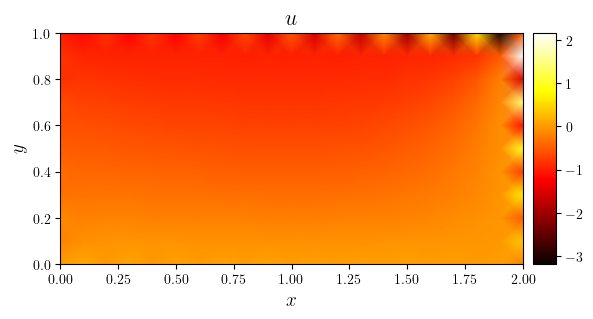

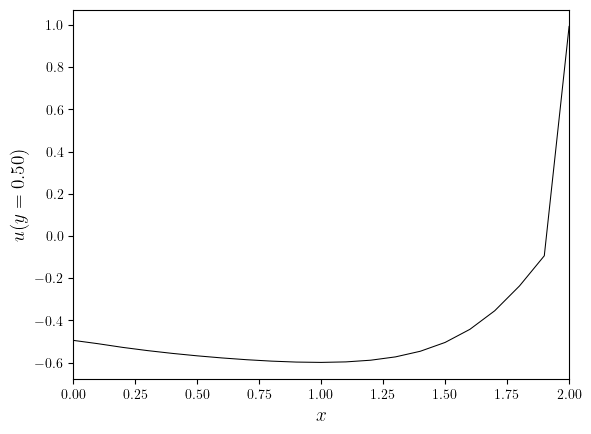

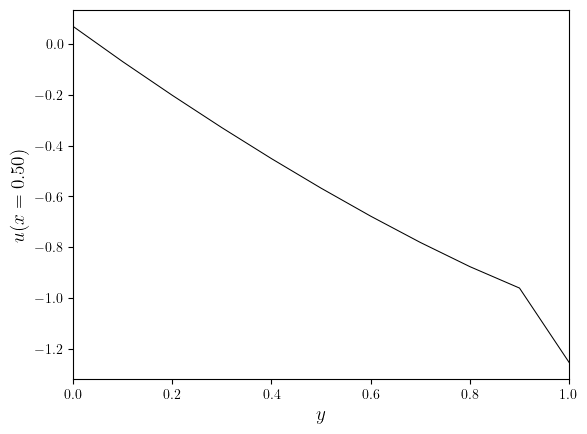

In [ ]:
fig, ax = plot_colormap(u, title=f'${u.name}$')
save_figure('u(x,y)', thumbnail=True)(fig)

ux, y_value = cross_section_grid(u, 'y', 0.5)
fig, ax = plot_line(ux, x_label='$x$', y_label=f'${u.name}(y={y_value:.2f})$')
save_figure(f'u(x,y={y_value:.2f})')(fig)

uy, x_value = cross_section_grid(u, 'x', 0.5)
fig, ax = plot_line(uy, x_label='$y$', y_label=f'${u.name}(x={y_value:.2f})$')
save_figure(f'u(x={x_value:.2f},y)')(fig)